# 一、数据的导入和预处理

In [1]:
%pwd

'C:\\Users\\lei\\Desktop\\顺丰-大数据挖掘与分析项目'

In [2]:
# 导入第三方包
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
# 数据读取
income = pd.read_excel(r'income.xlsx',engine="openpyxl")

In [3]:
income.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [4]:
income.shape

(32561, 15)

In [5]:
income.shape[0]

32561

In [6]:
income.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
income.tail(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [8]:
income.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
5812,44,Private,215479,HS-grad,9,Divorced,Transport-moving,Not-in-family,Black,Male,0,0,20,Haiti,<=50K
9157,22,Private,167868,HS-grad,9,Never-married,Sales,Not-in-family,White,Female,0,0,30,United-States,<=50K
6257,40,Private,436493,HS-grad,9,Never-married,Other-service,Own-child,White,Male,0,0,25,United-States,<=50K
32081,49,Local-gov,106554,Bachelors,13,Divorced,Prof-specialty,Unmarried,White,Female,0,0,40,United-States,>50K
6089,34,Private,221396,Some-college,10,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,<=50K
24876,69,NaN,180187,Assoc-acdm,12,Widowed,NaN,Not-in-family,White,Female,0,0,6,Italy,<=50K
21106,43,Private,178976,HS-grad,9,Never-married,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
29203,38,Private,150057,HS-grad,9,Never-married,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
28059,40,Private,202872,HS-grad,9,Married-civ-spouse,Sales,Wife,White,Female,0,0,40,United-States,>50K
14364,23,Private,175266,Some-college,10,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [9]:
income.isnull()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
32557,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
32558,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
32559,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
income.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [11]:
income['fnlwgt']

0         77516
1         83311
2        215646
3        234721
4        338409
          ...  
32556    257302
32557    154374
32558    151910
32559    201490
32560    287927
Name: fnlwgt, Length: 32561, dtype: int64

In [12]:
income['age'].isnull().sum()

np.int64(0)

In [13]:
# 查看数据集是否存在缺失值，这个其实和前面的income.isnull().sum()
# apply方法：调用函数进行批量化处理
income.apply(lambda x:np.sum(x.isnull()))

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

居民的收入数据集中有3个变量存在数值缺失，分别是居民的工作类型、职业和国籍。缺失值的存在一般都会影响分析或建模的结果，所以需要对缺失数值做相应
的处理。
处理有三种方式：

一是删除法，即将存在缺失的观测进行删除，如果缺失比例非常小，则删除法是比较合理的，反之，删除比例比较大的缺失值将会丢失一些有用的信息；

二是替换法，即使用一个常数对某个变量的缺失值进行替换，如果缺失的变量是离散型，则可以考虑用众数替换缺失值，如果缺失的变量是数值型，则可以考虑使用均值或中位数替换缺失值；

三是插补法，即运用模型方法，基于未缺失的变量预测缺失变量的值，如常见的回归插补法、多重插补法、拉格朗日插补法等。

In [3]:
# 缺失值处理
income.fillna(value = {'workclass':income.workclass.mode()[0],
                              'occupation':income.occupation.mode()[0],
                              'native-country':income['native-country'].mode()[0]}, inplace = True)
income.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
income.apply(lambda x:np.sum(x.isnull()))

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

# 二、数据的探索性分析

目的是了解数据背后的特征，如数据的集中趋势、离散趋势、数据形状和变量间的关系等。
首先，需要知道每个变量的基本统计值，如均值、中位数、众数等，只有了解了所需处理的数据特征，才能做到“心中有数”。

In [16]:
income.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [17]:
income.describe(include =['object'])

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,24532,10501,14976,5983,13193,27816,21790,29753,24720


其中描述中包含每个变量观测的数量（count）、不同离散值的个数（unique）、出现频次最高的离散值（top）和最高频次数（freq）。例如：以受教育水平变量为例，一共有16种不同的教育水平；3万多居民中，高中毕业的学历是出现最多的，一共有10 501名。

In [18]:
income.describe(include =['number'])

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


数据的分布形状（如偏度、峰度等）可以通过可视化的方法进行展现，这里仅以被调
查居民的年龄和每周工作小时数为例，绘制各自的分布形状图

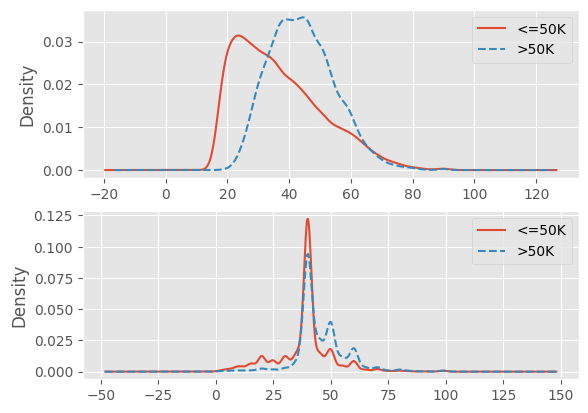

In [5]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 1)
# 不同收入水平下的年龄核密度图
income.age[income.income == ' <=50K'].plot(kind = 'kde', label = '<=50K', ax = axes[0], legend = True, linestyle = '-')
income.age[income.income == ' >50K'].plot(kind = 'kde', label = '>50K', ax = axes[0], legend = True, linestyle = '--')
# 不同收入水平下的周工作小时数和密度图
income['hours-per-week'][income.income == ' <=50K'].plot(kind = 'kde', label = '<=50K', ax = axes[1], legend = True, linestyle = '-')
income['hours-per-week'][income.income == ' >50K'].plot(kind = 'kde', label = '>50K', ax = axes[1], legend = True, linestyle = '--')
# 显示图形
plt.show()

第一幅图展现的是，在不同收入水平下，年龄的核密度分布图，对于年收入超过5万美元的居民来说，他们的年龄几乎呈现正态分布，而收入低于5万美元的居民，年龄呈现右偏特征，即年龄偏大的居民人数要比年龄偏小的人数多；第二幅图展现了不同收入水平下，周工作小时数的核密度图，很明显，两者的分布趋势非常相似，并且出现局部峰值。

也可以针对离散型变量，对比居民的收入水平高低在性别、种族状态、家庭关
系等方面的差异，进而可以发现这些离散变量是否影响收入水平

In [6]:
# 构造不同收入水平下各种族人数的数据
race = pd.DataFrame(income.groupby(by = ['race','income']).aggregate(np.size).loc[:,"age"])
race

age
race               income       
Amer-Indian-Eskimo <=50K     275
                   >50K       36
Asian-Pac-Islander <=50K     763
                   >50K      276
Black              <=50K    2737
                   >50K      387
Other              <=50K     246
                   >50K       25
White              <=50K   20699
                   >50K     7117

In [7]:
# 重设行索引
race = race.reset_index()
race

,race,income,age
0,Amer-Indian-Eskimo,<=50K,275
1,Amer-Indian-Eskimo,>50K,36
2,Asian-Pac-Islander,<=50K,763
3,Asian-Pac-Islander,>50K,276
4,Black,<=50K,2737
5,Black,>50K,387
6,Other,<=50K,246
7,Other,>50K,25
8,White,<=50K,20699
9,White,>50K,7117


In [8]:
# 变量重命名
race.rename(columns={'age':'counts'}, inplace=True)

In [9]:
race

,race,income,counts
0,Amer-Indian-Eskimo,<=50K,275
1,Amer-Indian-Eskimo,>50K,36
2,Asian-Pac-Islander,<=50K,763
3,Asian-Pac-Islander,>50K,276
4,Black,<=50K,2737
5,Black,>50K,387
6,Other,<=50K,246
7,Other,>50K,25
8,White,<=50K,20699
9,White,>50K,7117


In [10]:
# 排序
race.sort_values(by = ['race','counts'], ascending=False, inplace=True)

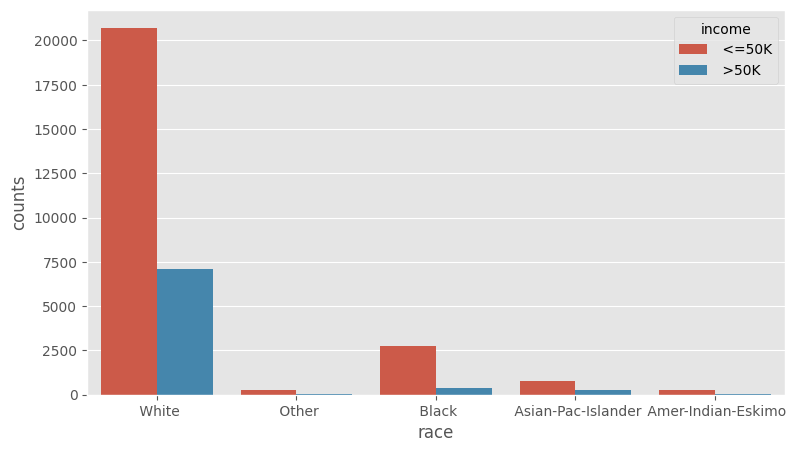

In [11]:
plt.figure(figsize=(9,5))
sns.barplot(x="race", y="counts", hue = 'income', data=race)
plt.show()

这可以看到不同种族的人群的收入差别非常大

# 三、数据建模

# 1、对离散变量进行编码

由于收入数据集中有很多离散型变量，这样的字符变量是不能直接用于建模的，需要对这些变量进行重编码，关于重编码的方法有多种，如将字符型的值转换为整数型的值、哑变量处理（0-1变量）、One-Hot热编码（类似于哑变量）等。在本项目中，采用“字符转数值”的方法对离散型变量进行重编码。

In [12]:
# 离散变量的重编码
for feature in income.columns:
    if income[feature].dtype == 'object':
        income[feature] = pd.Categorical(income[feature]).codes
income.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,38,0
1,50,5,83311,9,13,2,3,0,4,1,0,0,13,38,0
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,3,338409,9,13,2,9,5,2,0,0,0,40,4,0


In [13]:
income.dtypes

age               int64
workclass          int8
fnlwgt            int64
education          int8
education-num     int64
marital-status     int8
occupation         int8
relationship       int8
race               int8
sex                int8
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country     int8
income             int8
dtype: object

In [14]:
income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  int8 
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  int8 
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  int8 
 6   occupation      32561 non-null  int8 
 7   relationship    32561 non-null  int8 
 8   race            32561 non-null  int8 
 9   sex             32561 non-null  int8 
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  int8 
 14  income          32561 non-null  int8 
dtypes: int64(6), int8(9)
memory usage: 1.8 MB


所有的字符型变量都变成了整数型变量，如workclass、education、marital-status等，接下来就基于这个处理好的数据集对收入水平income进行预测。

在原本的居民收入数据集中，关于受教育程度的有两个变量，一个是education（教育水平），另一个是education-num（受教育时长），而且这两个变量的值都是一一对应的，只不过一个是字符型，另一个是对应的数值型，如果将这两个变量都包含在模型中的话，就会产生信息的冗余。其中该文件当中有fnlwgt变量代表的是一种序号，其对收入水平的高低并没有实际意义。
故为了避免冗余信息和无意义变量对模型的影响，考虑将education变量和fnlwgt变量从数据集中删除。

In [15]:
# 删除变量
income.drop(['education','fnlwgt'], axis = 1, inplace = True)
income.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,6,13,4,0,1,4,1,2174,0,40,38,0
1,50,5,13,2,3,0,4,1,0,0,13,38,0
2,38,3,9,0,5,1,4,1,0,0,40,38,0
3,53,3,7,2,5,0,2,1,0,0,40,38,0
4,28,3,13,2,9,5,2,0,0,0,40,4,0


In [16]:
income.shape

(32561, 13)

上面就是经处理“干净”的数据集，所要预测的变量就是income，该变量是二元变量，对其预测的实质就是对年收入水平的分类（一个新样本进来，通过分类模型，可以将该样本分为哪一种收入水平）

关于分类模型有很多种，如Logistic模型、决策树、K近邻、朴素贝叶斯模型、支持向量机、随机森林、梯度提升树GBDT模型等。本项目将对比使用K近邻和GBDT两种分类器，因为通常情况下，都会选用多个模型作为备选，通过对比才能得知哪种模型可以更好地拟合数据。

# 2、拆分数据集

基于上面的“干净”数据集，需要将其拆分为两个部分，一部分用于分类器模型的构建，另一部分用于分类器模型的评估，这样做的目的是避免分类器模型过拟合或欠拟合。如果模型在训练集上表现很好，而在测试集中表现很差，则说明分类器模型属于过拟合状态；如果模型在训练过程中都不能很好地拟合数据，那说明模型属于欠拟合状态。通常情况下，会把训练集和测试集的比例分配为75%和25%。

In [18]:
# 数据拆分
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(income.loc[:,'age':'native-country'], 
                                                    income['income'], train_size = 0.75, 
                                                    random_state = 1234)
print('训练数据集共有%d条观测' %X_train.shape[0])
print('测试数据集共有%d条观测' %X_test.shape[0])

训练数据集共有24420条观测
测试数据集共有8141条观测


结果显示，运用随机抽样的方法，将数据集拆分为两部分，其中训练数据集包含24 420条样本，测试数据集包含8 141条样本，下面将运用拆分好的训练数据集开始构建K近邻和GBDT两种分类器。

# 3、默认参数的模型构建

In [63]:
from sklearn import metrics
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["SimHei"]

## 3.1 默认的KNN模型

In [43]:
# 导入k近邻模型的类
from sklearn.neighbors import KNeighborsClassifier
# 构建k近邻模型
kn = KNeighborsClassifier()
kn.fit(X_train, y_train)
print(kn)

KNeighborsClassifier()


首先，针对K近邻模型，这里直接调用sklearn子模块neighbors中的KNeighborsClassifier类，并且使用模型的默认参数，即让K近邻模型自动挑选最佳的搜寻近邻算法（algorithm='auto'）、使用欧氏距离公式计算样本间的距离（p=2）、指定未知分类样本的近邻个数5（n_neighbors=5）而且所有近邻样本的权重都相等（weights='uniform'）。

In [44]:
# 预测测试集
kn_pred = kn.predict(X_test)
print(pd.crosstab(kn_pred, y_test))

income     0     1
row_0             
0       5645   724
1        581  1191


混淆矩阵，矩阵中的行是模型的预测值，矩阵中的列是测试集的实际值，主对角线就是模型预测正确的数量，副对角线就是模型预测错误的数量。

In [45]:
# 模型得分
print('模型在训练集上的准确率%f' %kn.score(X_train,y_train))
print('模型在测试集上的准确率%f' %kn.score(X_test,y_test))

模型在训练集上的准确率0.889926
模型在测试集上的准确率0.839700


经过计算，模型在训练集中的准确率为88.99%，但在测试集上的错误率超过16%（1-0.839），说明默认参数下的KNN模型可能存在过拟合的风险。模型的准确率就是基于混淆矩阵计算的，但是该方法存在一定的弊端，即如果数据本身存在一定的不平衡时（正负样本的比例差异较大），一定会导致准确率很高，但并不一定说明模型就是理想的。

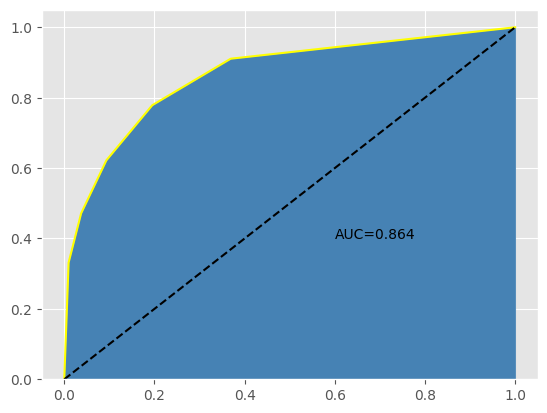

In [44]:
# 计算ROC曲线的x轴和y轴数据
fpr, tpr, _ = metrics.roc_curve(y_test, kn.predict_proba(X_test)[:,1])
# 绘制ROC曲线
plt.plot(fpr, tpr, linestyle = 'solid', color = 'yellow')
# 添加阴影
plt.stackplot(fpr, tpr, color = 'steelblue')
# 绘制参考线
plt.plot([0,1],[0,1], linestyle = 'dashed', color = 'black')
# 往图中添加文本
plt.text(0.6,0.4,'AUC=%.3f' % metrics.auc(fpr,tpr))
plt.show()

图中绘制了模型的ROC曲线，经计算得知，该曲线下的面积AUC为0.864。如果使用AUC来评估模型的好坏，那应该希望AUC越大越好。一般而言，当AUC的值超过0.8时，基本上就可以认为模型比较合理。所以，基于默认参数的K近邻模型在居民收入数据集上的表现还算理想。

## 3.2 默认的GBDT分类模型

In [50]:
# 导入GBDT模型的类
from sklearn.ensemble import GradientBoostingClassifier
# 构建GBDT模型
gbdt = GradientBoostingClassifier()
gbdt.fit(X_train, y_train)
print(gbdt)

GradientBoostingClassifier()


In [51]:
# 预测测试集
gbdt_pred = gbdt.predict(X_test)
print(pd.crosstab(gbdt_pred, y_test))

income     0     1
row_0             
0       5862   784
1        364  1131


In [52]:
# 模型得分
print('模型在训练集上的准确率%f' %gbdt.score(X_train,y_train))
print('模型在测试集上的准确率%f' %gbdt.score(X_test,y_test))

模型在训练集上的准确率0.869451
模型在测试集上的准确率0.858985


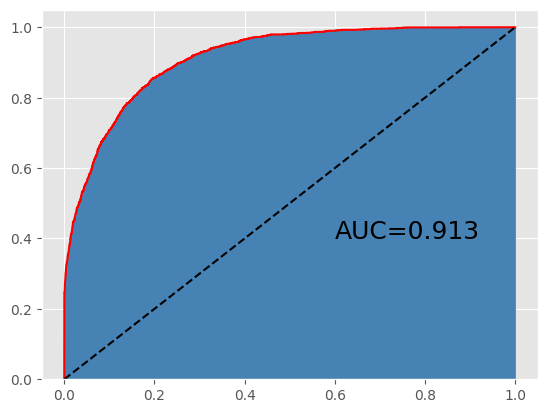

In [48]:
# 绘制ROC曲线
fpr, tpr, _ = metrics.roc_curve(y_test, gbdt.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, linestyle = 'solid', color = 'red')
plt.stackplot(fpr, tpr, color = 'steelblue')
plt.plot([0,1],[0,1], linestyle = 'dashed', color = 'black')
plt.text(0.6,0.4,'AUC=%.3f' % metrics.auc(fpr,tpr), fontdict = dict(size = 18))
plt.show()

## 3.3 默认的XGBboost分类模型

In [49]:
pip install xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 1.6/150.0 MB 6.5 MB/s eta 0:00:23
    --------------------------------------- 3.4/150.0 MB 8.8 MB/s eta 0:00:17
   - -------------------------------------- 4.7/150.0 MB 7.1 MB/s eta 0:00:21
   - -------------------------------------- 6.0/150.0 MB 7.0 MB/s eta 0:00:21
   -- ------------------------------------- 8.7/150.0 MB 8.0 MB/s eta 0:00:18
   -- ------------------------------------- 11.0/150.0 MB 8.6 MB/s eta 0:00:17
   --- ------------------------------------ 13.6/150.0 MB 9.0 MB/s eta 0:00:16
   ---- ----------------------------------- 16.0/150.0 MB 9.3 MB/s eta 0:00:15
   ---- ----------------------------------- 18.6/150.0 MB 9.6 MB/s eta 0:00:14
   ----- ---------------------------------- 19.4/150.0 MB 9.7 MB/s eta 0:00:14
   ------ --------------------------------- 22.5/150.0 MB 9.6 MB/s eta 0

income     0     1
row_0             
0       5741   680
1        485  1235
模型在训练集上的准确率0.949222
模型在测试集上的准确率0.856897


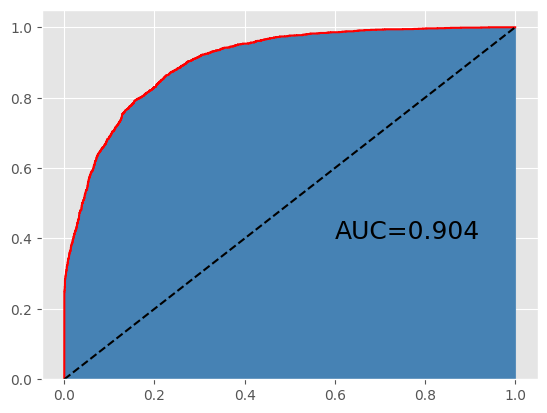

In [53]:
from xgboost import XGBClassifier
from sklearn import metrics
xgboost = XGBClassifier(objective='reg:logistic', n_estimators=1000)
xgboost.fit(X_train, y_train)
xgboost_pred = xgboost.predict(X_test)
print(pd.crosstab(xgboost_pred, y_test))
print('模型在训练集上的准确率%f' % xgboost.score(X_train, y_train))
print('模型在测试集上的准确率%f' % xgboost.score(X_test, y_test))
# 绘制ROC曲线
fpr, tpr, _ = metrics.roc_curve(y_test, xgboost.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, linestyle='solid', color='red')
plt.stackplot(fpr, tpr, color='steelblue')
plt.plot([0, 1], [0, 1], linestyle='dashed', color='black')
plt.text(0.6, 0.4, 'AUC=%.3f' % metrics.auc(fpr, tpr), fontdict=dict(size=18))
plt.show()


## 3.4 决策树

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [21]:
# 创建决策树分类器实例
dt_default = DecisionTreeClassifier(random_state=1234)
# 在训练集上训练模型
dt_default.fit(X_train, y_train)
# 在测试集上进行预测
y_test_pred = dt_default.predict(X_test)
# 评估模型性能
print('决策树模型在训练集上的准确率%f' % dt_default.score(X_train, y_train))
print('决策树模型在测试集上的准确率%f' % dt_default.score(X_test, y_test))

决策树模型在训练集上的准确率0.978419
决策树模型在测试集上的准确率0.812062


这个训练集和测试集准确率差别太大了说明过拟合情况很严重
并且下图的roc曲线效果也非常不好

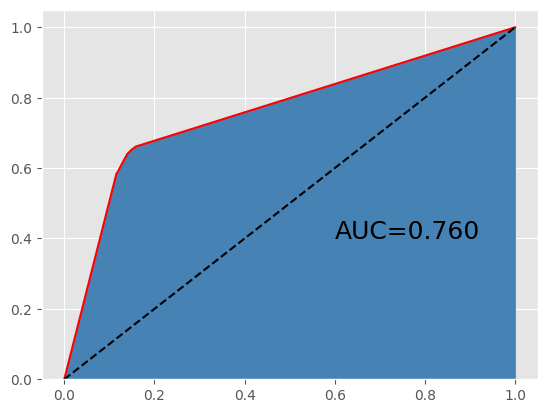

In [26]:
# 绘制ROC曲线
fpr, tpr, _ = metrics.roc_curve(y_test, dt_default.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, linestyle = 'solid', color = 'red')
plt.stackplot(fpr, tpr, color = 'steelblue')
plt.plot([0,1],[0,1], linestyle = 'dashed', color = 'black')
plt.text(0.6,0.4,'AUC=%.3f' % metrics.auc(fpr,tpr), fontdict = dict(size = 18))
plt.show()

## 3.5 SVM

income     0     1
row_0             
0       6059  1382
1        167   533
SVM模型在训练集上的准确率0.799877
SVM模型在测试集上的准确率0.809729


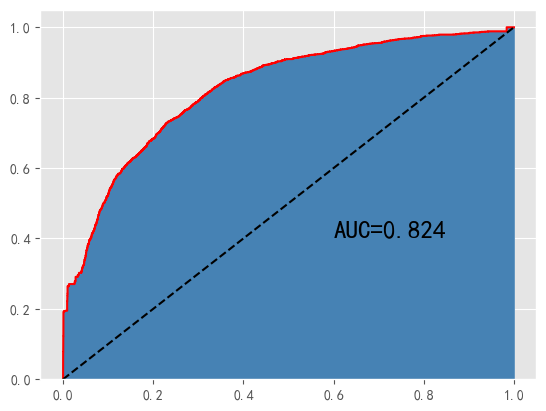

In [70]:
from sklearn.svm import SVC
svm = SVC(probability=True, random_state=1234) 
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print(pd.crosstab(svm_pred, y_test))
print('SVM模型在训练集上的准确率%f' % svm.score(X_train, y_train))
print('SVM模型在测试集上的准确率%f' % svm.score(X_test, y_test))
# 绘制ROC曲线
y_proba = svm.predict_proba(X_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_proba)
# 绘制ROC曲线
fpr, tpr, _ = metrics.roc_curve(y_test, svm.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, linestyle='solid', color='red')
plt.stackplot(fpr, tpr, color='steelblue')
plt.plot([0, 1], [0, 1], linestyle='dashed', color='black')
plt.text(0.6, 0.4, 'AUC=%.3f' % metrics.auc(fpr, tpr), fontdict=dict(size=18))
plt.show()

## 3.6 随机森林

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# 初始化默认参数的随机森林模型
rf = RandomForestClassifier(random_state=1234)
# 训练模型
rf.fit(X_train, y_train)
# 预测测试集
rf_pred = rf.predict(X_test)
# 输出混淆矩阵
print(pd.crosstab(rf_pred, y_test))
# 计算并打印训练集和测试集准确率
print('随机森林模型在训练集上的准确率%f' % rf.score(X_train, y_train))
print('随机森林模型在测试集上的准确率%f' % rf.score(X_test, y_test))
# 绘制ROC曲线（保持与之前模型相同的风格）
fpr, tpr, _ = metrics.roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, linestyle='solid', color='red')
plt.stackplot(fpr, tpr, color='steelblue')
plt.plot([0, 1], [0, 1], linestyle='dashed', color='black')
plt.text(0.6, 0.4, 'AUC=%.3f' % metrics.auc(fpr, tpr), fontdict=dict(size=18))
plt.show()

# 4.模型网格搜索

## 什么是Grid Search 网格搜索？
### Grid Search：一种调参手段；穷举搜索：在所有候选的参数选择中，通过循环遍历，尝试每一种可能性，表现最好的参数就是最终的结果。其原理就像是在数组里找最大值。（为什么叫网格搜索？以有两个参数的模型为例，参数a有3种可能，参数b有4种可能，把所有可能性列出来，可以表示成一个3*4的表格，其中每个cell就是一个网格，循环过程就像是在每个网格里遍历、搜索，所以叫grid search）


### 交叉验证经常与网格搜索进行结合，作为参数评价的一种方法，这种方法叫做grid search with cross validation。sklearn因此设计了一个这样的类GridSearchCV，这个类实现了fit，predict，score等方法，被当做了一个estimator，使用fit方法，该过程中：（1）搜索到最佳参数；（2）实例化了一个最佳参数的estimator；



## 4.1 网格搜索的最优KNN模型

In [46]:
# K近邻模型的网格搜索法
# 导入网格搜索法的函数
from sklearn.model_selection import GridSearchCV
# 选择不同的参数
k_options = list(range(1,12))
parameters = {'n_neighbors':k_options}
# 搜索不同的K值
grid_kn = GridSearchCV(estimator = KNeighborsClassifier(), param_grid = parameters, cv=10, scoring='accuracy', verbose=0, n_jobs=2)
# GridSearchCV函数中的几个参数含义:
# estimator参数接受一个指定的模型，这里为K近邻模型的类；
# param_grid用来指定模型需要搜索的参数列表对象，这里是K近邻模型中n_neighbors参数的11种可能值；
# cv是指网格搜索需要经过10重交叉验证；
# scoring指定模型评估的度量值，这里选用的是模型预测的准确率
grid_kn.fit(X_train, y_train)
print(grid_kn)
# 结果输出
print(grid_kn.best_params_,grid_kn.best_score_)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(), n_jobs=2,
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]},
             scoring='accuracy')
{'n_neighbors': 6} 0.8474610974610975


In [47]:
# 预测测试集
grid_kn_pred = grid_kn.predict(X_test)
print(pd.crosstab(grid_kn_pred, y_test))

income     0     1
row_0             
0       5826   866
1        400  1049


In [48]:
# 模型得分
print('模型在训练集上的准确率%f' %grid_kn.score(X_train,y_train))
print('模型在测试集上的准确率%f' %grid_kn.score(X_test,y_test))

模型在训练集上的准确率0.882596
模型在测试集上的准确率0.844491


比于默认参数的K近邻模型来说，经过网格搜索后的模型在训练数据集上的准确率下降了，但在测试数据集上的准确率提高了，这也是我们所期望的，说明优化后的模型在预测效果上更加优秀，并且两者差异的缩小也能够降低模型过拟合的可能。

In [53]:
grid_kn.predict_proba(X_test)

array([[0.66666667, 0.33333333],
       [0.66666667, 0.33333333],
       [1.        , 0.        ],
       ...,
       [1.        , 0.        ],
       [0.5       , 0.5       ],
       [1.        , 0.        ]], shape=(8141, 2))

## 4.2 网格搜索的最优GBDT模型

接下来，对GBDT模型的参数进行网格搜索，搜索的参数包含三个，分别是模型的学习速率、生成的基础决策树个数和每个基础决策树的最大深度

In [54]:
# GBDT模型的网格搜索法
# 选择不同的参数
from sklearn.model_selection import GridSearchCV
learning_rate_options = [0.01,0.03,0.05]
# max_depth_options = [1,3,5,7,9]
n_estimators_options = [100,300,500]
# parameters = {'learning_rate':learning_rate_options,'max_depth':max_depth_options,'n_estimators':n_estimators_options}
parameters = {'learning_rate': learning_rate_options, 'n_estimators':n_estimators_options}

grid_gbdt = GridSearchCV(estimator = GradientBoostingClassifier(), param_grid = parameters, cv=10, scoring='accuracy')
grid_gbdt.fit(X_train, y_train)

# 结果输出
# print(grid_gbdt)
print(grid_gbdt.cv_results_,grid_gbdt.best_params_,grid_gbdt.best_score_)

{'mean_fit_time': array([0.98672829, 3.31915097, 5.8459913 , 1.20184989, 3.64943211,
       6.0831666 , 1.13308487, 3.69044139, 5.88919811]), 'std_fit_time': array([0.05099563, 0.10541991, 0.47281576, 0.05000706, 0.55332742,
       0.65554534, 0.04671435, 0.28368993, 0.32649695]), 'mean_score_time': array([0.00388837, 0.01029828, 0.01670063, 0.00570893, 0.00956821,
       0.01490564, 0.00438843, 0.01073768, 0.01102872]), 'std_score_time': array([0.00178225, 0.00103304, 0.0024588 , 0.00143902, 0.00042361,
       0.00201295, 0.00099292, 0.00160402, 0.00143166]), 'param_learning_rate': masked_array(data=[0.01, 0.01, 0.01, 0.03, 0.03, 0.03, 0.05, 0.05, 0.05],
             mask=[False, False, False, False, False, False, False, False,
                   False],
       fill_value=1e+20), 'param_n_estimators': masked_array(data=[100, 300, 500, 100, 300, 500, 100, 300, 500],
             mask=[False, False, False, False, False, False, False, False,
                   False],
       fill_value=9

In [57]:
# 预测测试集
grid_gbdt_pred = grid_gbdt.predict(X_test)
print(pd.crosstab(grid_gbdt_pred, y_test))

# 模型得分
print('模型在训练集上的准确率%f' %grid_gbdt.score(X_train,y_train))
print('模型在测试集上的准确率%f' %grid_gbdt.score(X_test,y_test))

income     0     1
row_0             
0       5853   701
1        373  1214
模型在训练集上的准确率0.879730
模型在测试集上的准确率0.868075


## 4.3 网格搜索的最优XGBOOST模型

In [55]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
params = {'max_depth': [3, 6, 10], # 树的最大深度
          'learning_rate': [0.01, 0.05, 0.1], #学习率
        #   'n_estimators': [100, 500, 1000], #树的数量
        #   'colsample_bytree': [0.3, 0.7]    #每棵树使用的特征比例
        }
xgbr = xgb.XGBClassifier(seed=123456)
grid_xgboost = GridSearchCV(estimator=xgbr,#基础模型
                   param_grid=params,      #参数网络
                   scoring='accuracy', 
                   verbose=1)              #显示训练进度
grid_xgboost.fit(X_train, y_train)
print("Best parameters:", grid_xgboost.best_params_)


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 6}


In [56]:
# 预测测试集
grid_xgboost_pred = grid_xgboost.predict(X_test)
print(pd.crosstab(grid_xgboost_pred, y_test))
# 模型得分
print('模型在训练集上的准确率%f' %grid_xgboost.score(X_train, y_train))
print('模型在测试集上的准确率%f' %grid_xgboost.score(X_test,y_test))

income     0     1
row_0             
0       5836   668
1        390  1247
模型在训练集上的准确率0.885954
模型在测试集上的准确率0.870041


## 4.4 网格搜索的最优决策树模型

In [27]:
from sklearn.model_selection import GridSearchCV
# 定义参数网格
param_grid = {
    'max_depth': [3, 5, 7, 9, 11],  # 树的最大深度
    'min_samples_split': [2, 5, 10],  # 分割内部节点所需的最小样本数
    'min_samples_leaf': [1, 2, 5],  # 叶节点所需的最小样本数
    'criterion': ['gini', 'entropy']  # 特征选择标准
}
# 网格搜索
grid_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=1234),
                          param_grid=param_grid,
                          cv=5, 
                          scoring='accuracy')
grid_dt.fit(X_train, y_train)
print("best_estimator:",grid_dt.best_estimator_)
# 预测测试集
grid_dt_pred = grid_dt.predict(X_test)
print(pd.crosstab(grid_dt_pred, y_test))
print('决策树模型在训练集上的准确率%f' %grid_dt.score(X_train, y_train))
print('决策树模型在测试集上的准确率%f' %grid_dt.score(X_test, y_test))

best_estimator: DecisionTreeClassifier(criterion='entropy', max_depth=11, min_samples_leaf=5,
                       random_state=1234)
income     0     1
row_0             
0       5813   788
1        413  1127
决策树模型在训练集上的准确率0.870639
决策树模型在测试集上的准确率0.852475


### 特征重要性分析

In [36]:
# 获取特征重要性
best_dt = grid_dt.best_estimator_
feature_importance = best_dt.feature_importances_  # 特征重要性得分
feature_names = X_train.columns  # 获取特征列名
importance_df = pd.DataFrame({
    '特征名称': feature_names,
    '重要性得分': feature_importance
})
# 按重要性排序
feature_importance = importance_df.sort_values('重要性得分', ascending=False)
# 显示前5个重要特征
print('前5个重要特征:')
print(importance_df.head(5))

前5个重要特征:
             特征名称     重要性得分
0             age  0.084130
1       workclass  0.015076
2   education-num  0.188329
3  marital-status  0.003513
4      occupation  0.018359


## 4.5 网格搜索的最优SVM模型

In [ ]:
# 定义SVM的参数网格
C_options = [0.1, 1, 10]  # 正则化参数，控制惩罚力度，值越大惩罚越强
kernel_options = ['linear', 'rbf', 'poly']  # 核函数类型
gamma_options = ['scale', 'auto']  # 核函数系数（对rbf、poly有效）

# 组合参数网格
parameters = {
    'C': C_options,
    'kernel': kernel_options,
    'gamma': gamma_options
}

# 网格搜索
grid_svm = GridSearchCV(
    estimator=SVC(probability=True, random_state=1234),  # 启用概率估计，保证可复现性
    param_grid=parameters,
    cv=10,
    scoring='accuracy'
)
grid_svm.fit(X_train, y_train)
print(grid_svm.cv_results_, grid_svm.best_params_, grid_svm.best_score_)
# 预测测试集
grid_svm_pred = grid_svm.predict(X_test)
print(pd.crosstab(grid_svm_pred, y_test))
# 模型得分
print('SVM模型在训练集上的准确率%f' % grid_svm.score(X_train, y_train))
print('SVM模型在测试集上的准确率%f' % grid_svm.score(X_test, y_test))

## 4.6 网格搜索的最优随机森林模型

In [ ]:
from sklearn.ensemble import RandomForestClassifier
n_estimators_options = [100, 300, 500]  # 树的数量
max_depth_options = [None, 10, 20, 30]  # 树的最大深度（None表示不限制）
min_samples_split_options = [2, 5, 10]  # 分裂内部节点所需的最小样本数
min_samples_leaf_options = [1, 2, 4]  # 叶节点所需的最小样本数
parameters = {
    'n_estimators': n_estimators_options,
    'max_depth': max_depth_options,
    'min_samples_split': min_samples_split_options,
    'min_samples_leaf': min_samples_leaf_options
}
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=1234),  # 固定随机种子，保证可复现性
    param_grid=parameters,
    cv=10,  
    scoring='accuracy'  # 相同的评估指标
)
grid_rf.fit(X_train, y_train)
print(grid_rf.cv_results_, grid_rf.best_params_, grid_rf.best_score_)
# 预测测试集
grid_rf_pred = grid_rf.predict(X_test)
print(pd.crosstab(grid_rf_pred, y_test))
# 模型得分（输出格式与其他模型统一）
print('随机森林模型在训练集上的准确率%f' % grid_rf.score(X_train, y_train))
print('随机森林模型在测试集上的准确率%f' % grid_rf.score(X_test, y_test))

# 5、模型对比

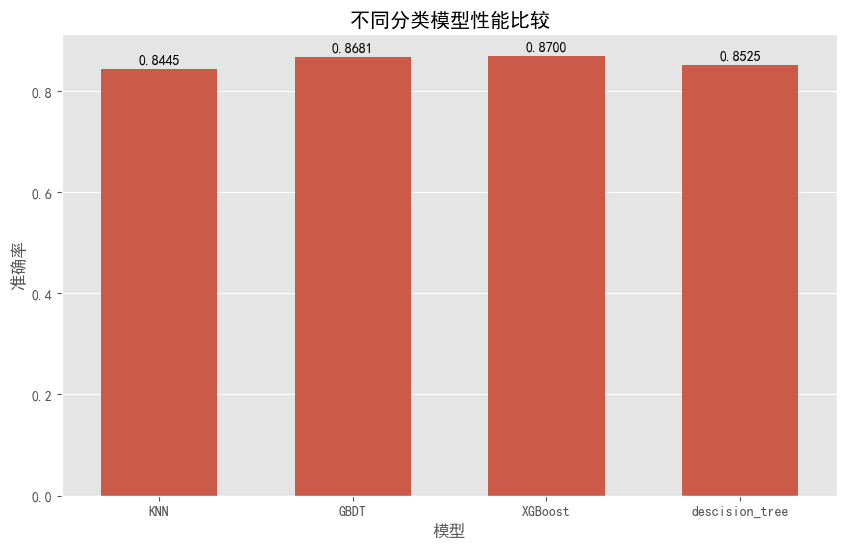

In [68]:
# 评估所有模型性能
models = ['KNN', 'GBDT', 'XGBoost','descision_tree','SVM','RANDOM_FOREST']
accuracies = [grid_kn.score(X_test,y_test),grid_gbdt.score(X_test,y_test),grid_xgboost.score(X_test,y_test),
              grid_dt.score(X_test, y_test),grid_svm.score(X_test, y_test),grid_rf.score(X_test, y_test)]
# 比较结果可视化
import seaborn as sns
plt.figure(figsize=(10, 6))
ax=sns.barplot(x='模型', y='准确率', data=pd.DataFrame({ '准确率': accuracies,'模型': models}),width=0.6)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.01,
            '{:.4f}'.format(height),
            ha="center")
plt.title('不同分类模型性能比较')
plt.show()

### Grid Search 调参方法存在的共性弊端就是：耗时；参数越多，候选值越多，耗费时间越长！所以，一般情况下，先定一个大范围，然后再细化。
### Grid Search：一种调优方法，在参数列表中进行穷举搜索，对每种情况进行训练，找到最优的参数；由此可知，这种方法的主要缺点是 比较耗时！